In [1]:
!pip3 install -r requirements.txt


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from huggingface_hub import snapshot_download

In [3]:
dataset_path = snapshot_download(repo_id="biglab/webui-7kbal", repo_type="dataset")
dataset_path

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

'C:\\Users\\70133\\.cache\\huggingface\\hub\\datasets--biglab--webui-7kbal\\snapshots\\2312ad12c6df0715fd808a934cc37ada255517b5'

In [4]:
import enum
import os
import zipfile
import gzip
import json
from glob import glob
import re
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

In [5]:
# Create output dir
d1_path = os.path.join(dataset_path, "dataset1")
if not os.path.exists(d1_path):
    os.mkdir(d1_path)

## Dataset decompression

This code will unpack files only for the first time

In [6]:
def unpack():
    # Merge split zip parts in binary mode so it works on Windows too.
    parts = sorted(glob(os.path.join(dataset_path, "*.zip*")))
    output = os.path.join(d1_path, "dataset.zip")
    if not parts:
        print("WARNING : no zip parts found")
        return False

    extracted_dirs = [x for x in os.listdir(d1_path) if os.path.isdir(os.path.join(d1_path, x))]
    if extracted_dirs:
        return True

    if not zipfile.is_zipfile(output):
        with open(output, "wb") as dst:
            for part in parts:
                with open(part, "rb") as src:
                    while True:
                        chunk = src.read(1024 * 1024)
                        if not chunk:
                            break
                        dst.write(chunk)

    if not zipfile.is_zipfile(output):
        print("WARNING : bad zip format")
        return False

    with zipfile.ZipFile(output, 'r') as z:
        z.extractall(d1_path)

    return True

In [7]:
unpack()

True

## Loading files

In [8]:
dirs = [x for x in os.listdir(d1_path) if os.path.isdir(os.path.join(d1_path, x))]
if len(dirs) == 1:
    dataset_dir = dirs[0]
else:
    dataset_dir = "balanced_7k" #"train_split_web7k"  # SET MANUALLY

In [9]:
#d1_path = r'C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7k\snapshots\666\dataset1'
files = os.path.join(d1_path, dataset_dir)
base_data_path = d1_path
print(files)
print("files number", len(os.listdir(files)))

C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\balanced_7k
files number 6402


In [10]:
# Load pages metadata

metadata_rel_dir = Path("webui") / "metadata" / "screenclassification"
repo_root = next((candidate for candidate in [Path.cwd(), *Path.cwd().parents]
                  if (candidate / metadata_rel_dir / "class_map_enrico.json").exists()), None)
if repo_root is None:
    raise FileNotFoundError(f"Could not find {metadata_rel_dir / 'class_map_enrico.json'} from {Path.cwd()}")

class_map_path = repo_root / metadata_rel_dir / "class_map_enrico.json"
silver_csv_path = repo_root / metadata_rel_dir / "silver_webui-multi_topic.csv"

with open(class_map_path, 'r', encoding='utf-8') as f:
    labels = list(json.load(f)["idx2Label"].values())
#dtypes = {**{'page_id': object, 'file': object}, **dict([(x, np.float64) for x in labels])}
dtypes = {**{'page_id': np.int64, 'file': object}, **dict([(x, np.float64) for x in labels])}

df_c = pd.read_csv(silver_csv_path, sep=r'[,\\]', names=['page_id', 'file', *labels], dtype=dtypes, engine='python')
df_c['label_max'] = df_c[labels].idxmax(axis=1)
df_c['certainty'] = df_c[labels].max(axis=1)
df_cf = df_c.set_index(['page_id', 'file']).sort_index()
assert df_cf.index.is_unique

In [11]:
df_c.head(5)

,page_id,file,bare,calculator,camera,chat,editor,form,gallery,list,...,modal,news,other,profile,search,settings,terms,tutorial,label_max,certainty
0,1655879187811,default_1280-720-screenshot.webp,9.291674e-11,7.130765e-08,7.253227e-06,9.046539e-06,8.187051e-09,7.984676e-08,2.324591e-06,0.983791,...,1.108446e-03,1.410034e-02,1.907439e-04,2.310613e-08,4.906302e-05,4.191939e-05,6.378857e-04,7.004751e-08,list,0.983791
1,1655879187811,default_1536-864-screenshot.webp,1.109577e-12,3.087419e-10,9.532457e-10,1.385165e-11,1.341835e-09,3.822118e-09,1.366081e-09,0.000013,...,1.148793e-04,3.088464e-07,9.998707e-01,1.503188e-10,1.038731e-09,1.253137e-10,5.714059e-08,9.233252e-07,other,0.999871
2,1655879187811,iPad-Pro-screenshot.webp,4.476726e-10,2.628705e-07,4.739139e-05,8.027262e-07,1.768409e-09,3.327144e-06,2.086888e-06,0.946450,...,1.890350e-04,6.831510e-04,1.278714e-07,2.380704e-06,2.039391e-04,1.932175e-03,1.641989e-03,9.453231e-07,list,0.946450
3,1655879187811,iPhone-13 Pro-screenshot.webp,1.740975e-11,2.117407e-08,2.220893e-10,6.500039e-13,3.749291e-13,8.293891e-10,1.001302e-10,0.000012,...,4.523345e-09,2.618951e-01,2.998420e-11,7.362105e-03,2.464764e-07,2.476263e-10,7.307301e-01,6.493919e-07,terms,0.730730
4,1655884447196,iPad-Pro-screenshot.webp,1.347118e-05,6.677556e-03,1.288787e-03,2.742077e-05,8.803538e-05,3.809738e-07,4.067358e-02,0.000673,...,7.473713e-06,2.308492e-01,6.170149e-07,1.024725e-01,6.051495e-01,2.472414e-05,9.113838e-05,8.508272e-03,search,0.605150


In [12]:
# Take max of each screenshot and save it
df_c['label_max'] = df_c[labels].idxmax(axis=1)
df_c['certainty'] = df_c[labels].max(axis=1)

df_cf = (df_c.set_index(['page_id', 'file']).sort_index())      # index = (page_id, file)
assert df_cf.index.is_unique   

In [13]:
df_cf.head(5)

bare    calculator  \
page_id       file                                                           
1655879187811 default_1280-720-screenshot.webp  9.291674e-11  7.130765e-08   
              default_1536-864-screenshot.webp  1.109577e-12  3.087419e-10   
              iPad-Pro-screenshot.webp          4.476726e-10  2.628705e-07   
              iPhone-13 Pro-screenshot.webp     1.740975e-11  2.117407e-08   
1655884447196 iPad-Pro-screenshot.webp          1.347118e-05  6.677556e-03   

                                                      camera          chat  \
page_id       file                                                           
1655879187811 default_1280-720-screenshot.webp  7.253227e-06  9.046539e-06   
              default_1536-864-screenshot.webp  9.532457e-10  1.385165e-11   
              iPad-Pro-screenshot.webp          4.739139e-05  8.027262e-07   
              iPhone-13 Pro-screenshot.webp     2.220893e-10  6.500039e-13   
1655884447196 iPad-Pro-screenshot.webp          1.288787e-03  2.742077e-05   

                                                      editor          form  \
page_id       file                                                           
1655879187811 default_1280-720-screenshot.webp  8.187051e-09  7.984676e-08   
              default_1536-864-screenshot.webp  1.341835e-09  3.822118e-09   
              iPad-Pro-screenshot.webp          1.768409e-09  3.327144e-06   
              iPhone-13 Pro-screenshot.webp     3.749291e-13  8.293891e-10   
1655884447196 iPad-Pro-screenshot.webp          8.803538e-05  3.809738e-07   

                                                     gallery      list  \
page_id       file                                                       
1655879187811 default_1280-720-screenshot.webp  2.324591e-06  0.983791   
              default_1536-864-screenshot.webp  1.366081e-09  0.000013   
              iPad-Pro-screenshot.webp          2.086888e-06  0.946450   
              iPhone-13 Pro-screenshot.webp     1.001302e-10  0.000012   
1655884447196 iPad-Pro-screenshot.webp          4.067358e-02  0.000673   

                                                       login          maps  \
page_id       file                                                           
1655879187811 default_1280-720-screenshot.webp  4.828995e-08  6.712814e-12   
              default_1536-864-screenshot.webp  2.989208e-07  1.240250e-15   
              iPad-Pro-screenshot.webp          3.144533e-08  1.722613e-10   
              iPhone-13 Pro-screenshot.webp     1.002917e-11  3.034406e-12   
1655884447196 iPad-Pro-screenshot.webp          1.071961e-04  1.921105e-03   

                                                ...         modal  \
page_id       file                              ...                 
1655879187811 default_1280-720-screenshot.webp  ...  1.108446e-03   
              default_1536-864-screenshot.webp  ...  1.148793e-04   
              iPad-Pro-screenshot.webp          ...  1.890350e-04   
              iPhone-13 Pro-screenshot.webp     ...  4.523345e-09   
1655884447196 iPad-Pro-screenshot.webp          ...  7.473713e-06   

                                                        news         other  \
page_id       file                                                           
1655879187811 default_1280-720-screenshot.webp  1.410034e-02  1.907439e-04   
              default_1536-864-screenshot.webp  3.088464e-07  9.998707e-01   
              iPad-Pro-screenshot.webp          6.831510e-04  1.278714e-07   
              iPhone-13 Pro-screenshot.webp     2.618951e-01  2.998420e-11   
1655884447196 iPad-Pro-screenshot.webp          2.308492e-01  6.170149e-07   

                                                     profile        search  \
page_id       file                                                           
1655879187811 default_1280-720-screenshot.webp  2.310613e-08  4.906302e-05   
              default_1536-864-screenshot.webp  1.503188e-10  1.038731e-09   
      

In [14]:
df_cf["label_max"].value_counts()

label_max
tutorial       176323
news            82991
list            68810
gallery         64452
modal           56708
terms           55117
menu            44860
login           40232
profile         38755
mediaplayer     32966
bare            27064
other           14979
calculator      14120
search          13933
form            13678
settings        11339
camera           8813
editor           5108
chat             2117
maps             1966
Name: count, dtype: int64

## Dataset parsing

In [15]:
class FileType(enum.StrEnum):
    """
    Enum containing all filetypes
    """

    AXTree = "axtree.json.gz",
    BB = "bb.json.gz",
    Box = "box.json.gz",
    Class = "class.json.gz",
    HTML = "html.html",
    Links = "links.json",
    ScreenFull = "screenshot-full.webp",
    Screen = "screenshot.webp",
    Style = "style.json.gz",
    URL = "url.txt",
    Viewport = "viewport.json.gz"

# Helper functions

def ft_is_gz(ft: FileType) -> bool:
    """
    Check if a FileType is a gz file
    """
    return ft in [FileType.AXTree, FileType.BB, FileType.Box, FileType.Class, FileType.Style, FileType.Viewport]

def ft_is_json(ft: FileType) -> bool:
    """
    Check if a FileType is in json format
    """
    return ft in [FileType.AXTree, FileType.BB, FileType.Box, FileType.Class, FileType.Links, FileType.Style, FileType.Viewport]

def ft_is_webp(ft: FileType) -> bool:
    """
    Check if a FileType is a webp image
    """
    return ft in [FileType.ScreenFull, FileType.Screen]

In [16]:
class Page():
    """
    A class which loads page content (screen)
    """
    def __init__(self, path, screen_type: str, debug: bool = True):
        self.screen_type = screen_type
        self.path = path
        self.skip = False

        # Parse screen type
        self.desktop = screen_type.startswith("default")
        if self.desktop:
            (self.width, self.height) = tuple(map(int, screen_type.split('_')[1].split('-')))
        else:
            (self.width, self.height) = (0, 0)

        # Load filenames
        #files = list(filter(lambda x: x.startswith(screen_type), os.listdir(path)))
        self.fnames = dict()
        self.files = dict()
        missing = False

        for ft in FileType:
            file_path = screen_type + "-" + ft.value
            if os.path.exists(os.path.join(self.path, file_path)):
                self.fnames[ft] = file_path
            else:
                missing = True


        if missing:
            # Some files are missing
            if debug:
                for ft, v in self.fnames.items():
                    assert ft_is_webp(ft), "Page::__init__() : non-webp file in partial download : {}".format(v)
            self.skip = True


    def load(self, debug: bool = True, *args):
        if self.skip:
            return
        if len(args) == 0:
            ftypes = FileType
        else:
            ftypes = args

        for ft in ftypes:
            file_path = Path(self.path) / self.fnames[ft]
            if debug:
                print("Page::load() : loading file {}...".format(self.fnames[ft]))

            if ft_is_webp(ft):
                # Check if the file is empty
                if file_path.stat().st_size == 0:
                    if debug:
                        print("Page::load() : {} is empty".format(self.fnames[ft]))
                    continue
                with file_path.open("rb") as raw_f:
                    image = Image.open(raw_f)
                    image.load()
                    self.files[ft] = image

            elif ft_is_gz(ft):
                # gzip
                with file_path.open("rb") as raw_f:
                    with gzip.open(raw_f, "rb") as f:
                        if ft_is_json(ft):
                            self.files[ft] = json.load(f)
                        else:
                            # plaintext
                            self.files[ft] = f.read()
            else:
                # not compressed
                with file_path.open("r", encoding="utf-8", errors="replace") as f:
                    if ft_is_json(ft):
                        self.files[ft] = json.load(f)
                    else:
                        # plaintext
                        self.files[ft] = f.read()
                        

class PageLoader():
    """
    A class which loads multiple pages (with different resolutions). Loads only labels of the specified class
    """
    def __init__(self, path, debug: bool = True, *args):
        self.path = path
        self.page_id = np.int64(os.path.basename(path))

        #print('\nID:', self.page_id)
        self.skip = False

        if debug:
            print("PageLoader()::__init__() : opening", self.page_id)
            #print(os.listdir(self.path))

        # Extract pages
        prefixes = map(lambda x: '-'.join(x.split('-')[:-1]), os.listdir(self.path))
        screen_types = list(filter(lambda x: x.find("screenshot") == -1, list(set(prefixes))))

        # Load pages
        self.pages = dict()
        for s in screen_types:
            page = Page(self.path, s, debug)
            if not page.skip:
                self.pages[s] = page
                self.pages[s].load(debug, *args) # load all

        # Find best page(with bigest width)
        self.best = next(
                (p for p in sorted(self.pages.values(), reverse=True, key=lambda p: p.width)
                 if p.files.get(FileType.ScreenFull)), None)
        
        
        # set screen_type, label and certainty for best Page
        metadata_df = globals().get("df_cf")
        try:
            self.screen_type = self.best.screen_type
        except AttributeError:
            self.screen_type = ''

        if metadata_df is None or not self.screen_type:
            self.label = ''
            self.certainty = 0.0
        else:
            try:
                self.label = metadata_df.loc[(self.page_id, self.screen_type + '-screenshot.webp'), 'label_max']
            except KeyError:
                self.label = ''
            try:
                self.certainty = metadata_df.loc[(self.page_id, self.screen_type + '-screenshot.webp'), 'certainty']
            except KeyError:
                self.certainty = 0.0

    
    def image(self) -> [Image.Image, None]:
        """
        Find and return the largest page image width. Desktop images always have the largest priority
        """
        if self.best and self.best.files.get(FileType.ScreenFull) is not None:
            return self.best.files[FileType.ScreenFull]
        return None

In [17]:
def label_certainty_thresh(c: np.float64) -> bool:      
    return c >= 0.6

In [18]:
def preview(img: Image.Image, width: int) -> Image.Image:
    return img.resize((width, int(img.height / img.width * width)))

In [19]:
# _ = plt.figure(figsize=(36, 20)) # 1920/1080 scaled to 360p
# (nrows, ncols) = (5, 5) # Set the grid size
# start = nrows*ncols # Start index
# skip = 0

# files_l = sorted(os.listdir(files))
# # for index in range(0, nrows*ncols):
# for index in range(0, nrows*ncols):
#     while True: # Find matching
#         fpath = files_l[index + start + skip]
#         # Parse the page
#         loader = PageLoader(os.path.join(files, fpath), debug=False)
#         if not label_certainty_thresh(loader.certainty):
#             skip += 1
#             continue # Skip

#         # Create a subplot and render an image
#         ax = plt.subplot(nrows, ncols, index+1)
#         _ = plt.title(loader.label)
#         _, _ = plt.xticks([]), plt.yticks([]);
#         image = loader.image()
#         if image is not None:
#             _ = plt.imshow(preview(image, 360))
#             print(loader.page_id, end=' ')
#             if index % ncols == 4:
#                 print('')
#         else:
#             skip += 1
#             continue # Load the next sample
#         # Else found
#         break
# _ = plt.show()

## Bounding Boxes

dict_keys(['default_1280-720', 'iPhone-13 Pro', 'default_1536-864', 'iPad-Pro', 'default_1920-1080', 'default_1366-768'])
screen_type: default_1920-1080 page_id: 1655886594268 label: calculator


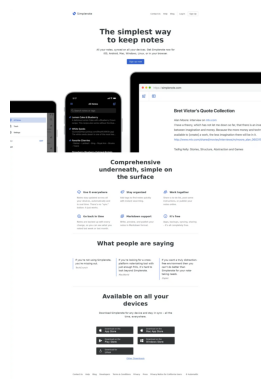

In [20]:
# Take 1655885631145 since it is in huggingface dataset
path = os.path.join(files, '1655886594268')  # 1655888953458  1655905777432
loader = PageLoader(path, debug=False)

# Show
print(loader.pages.keys())
print('screen_type:', loader.screen_type, 'page_id:', loader.page_id, 'label:', loader.label)
plt.imshow(loader.image())
plt.axis("off")
plt.show()

In [21]:
# AXTree
nodes = loader.best.files[FileType.AXTree]['nodes']
print(type(loader.best.files[FileType.AXTree]))
print(json.dumps(nodes, indent=2, ensure_ascii=False))

<class 'dict'>
[
  {
    "nodeId": "1",
    "ignored": false,
    "role": {
      "type": "internalRole",
      "value": "RootWebArea"
    },
    "name": {
      "type": "computedString",
      "value": "Simplenote",
      "sources": [
        {
          "type": "relatedElement",
          "attribute": "aria-labelledby"
        },
        {
          "type": "attribute",
          "attribute": "aria-label"
        },
        {
          "type": "attribute",
          "attribute": "aria-label",
          "superseded": true
        },
        {
          "type": "relatedElement",
          "value": {
            "type": "computedString",
            "value": "Simplenote"
          },
          "nativeSource": "title"
        },
        {
          "type": "attribute",
          "attribute": "title",
          "superseded": true
        }
      ]
    },
    "properties": [
      {
        "name": "focusable",
        "value": {
          "type": "booleanOrUndefined",
          "value": t

In [22]:
# BB
bb = loader.best.files.get(FileType.BB)

# turn bb keys to int
bb = { int(b_id): b for b_id, b in bb.items() }

print(type(bb))
for b_id, b in bb.items():
    print(b_id, b)

<class 'dict'>
3 {'x': 0, 'y': 0, 'width': 1920, 'height': 1080}
4 {'x': 893.5, 'y': 384.375, 'width': 133, 'height': 39}
5 {'x': 480, 'y': 0, 'width': 148, 'height': 72}
6 {'x': 0, 'y': 479.375, 'width': 1920, 'height': 620}
7 {'x': 660, 'y': 297.984375, 'width': 600, 'height': 57.59375}
9 {'x': 480, 'y': 0, 'width': 960, 'height': 72}
10 {'x': 480, 'y': 23, 'width': 24, 'height': 24}
11 {'x': 1059, 'y': 0, 'width': 381, 'height': 72}
13 {'x': 660, 'y': 144, 'width': 600, 'height': 279.375}
14 {'x': 514, 'y': 24, 'width': 114, 'height': 24}
15 {'x': 0, 'y': 144, 'width': 1920, 'height': 2547.5625}
16 {'x': 686, 'y': 142, 'width': 548, 'height': 126.59375}
17 {'x': 661.5, 'y': 300.984375, 'width': 598, 'height': 49.796875}
18 {'x': 660, 'y': 384.375, 'width': 600, 'height': 39}
19 {'x': 911.5, 'y': 394.375, 'width': 97, 'height': 19}
20 {'x': 0, 'y': 479.375, 'width': 1920, 'height': 620}
21 {'x': 0, 'y': 0, 'width': 1920, 'height': 2835.5625}
22 {'x': 0, 'y': 0, 'width': 1920, 'height

In [23]:
# map backendDOMNodeId -> AXTree node
backend_id_to_axnode = {
    node.get("backendDOMNodeId"): node
    for node in nodes
    if "backendDOMNodeId" in node
}

bb_info = {}
for b_id, b in bb.items():
    ax_node = backend_id_to_axnode.get(b_id)
    if not ax_node:
        continue

    bb_info[b_id] = {
        "name": ax_node.get("name", {}).get("value", ""),
        "name_t": ax_node.get("name", {}).get("type", ""),
        "role": ax_node.get("role", {}).get("value", ""),
        "role_t": ax_node.get("role", {}).get("type", ""),
        "ignored": ax_node.get("ignored", False),
        "box": b
    }

# print(type(backend_id_to_axnode), json.dumps(backend_id_to_axnode, indent=2, ensure_ascii=False))
# print(type(bb_info),'\n', json.dumps(bb_info, indent=2, ensure_ascii=False))

In [24]:
ignored_ids = [] 
for x_id, x in bb_info.items():
    if x["ignored"] == True:
        print(x_id, x['ignored'], x['role_t'], x['role'], '"', x['name'], '"', x['box'])
        ignored_ids.append(x_id)

print(set(ignored_ids))

10 True role none "  " {'x': 480, 'y': 23, 'width': 24, 'height': 24}
13 True role none "  " {'x': 660, 'y': 144, 'width': 600, 'height': 279.375}
18 True role none "  " {'x': 660, 'y': 384.375, 'width': 600, 'height': 39}
21 True role none "  " {'x': 0, 'y': 0, 'width': 1920, 'height': 2835.5625}
23 True role none "  " {'x': -9999, 'y': 0, 'width': 0, 'height': 0}
24 True role none "  " None
25 True role none "  " None
26 True role none "  " None
27 True role none "  " None
28 True role none "  " None
29 True role none "  " None
30 True role none "  " None
31 True role none "  " None
32 True role none "  " None
33 True role none "  " {'x': -9999, 'y': 0, 'width': 0, 'height': 0}
34 True role none "  " None
35 True role none "  " None
36 True role none "  " None
37 True role none "  " None
38 True role none "  " None
39 True role none "  " None
40 True role none "  " None
41 True role none "  " None
42 True role none "  " None
43 True role none "  " {'x': -9999, 'y': 0, 'width': 0, 'he

In [25]:
unic = {info["name_t"] for info in bb_info.values()}
print(unic)

{'', 'computedString'}


In [26]:
# roles filter
allowed_roles = {info["role"] for info in bb_info.values()}
print(allowed_roles)
# allowed_roles.discard('StaticText')
# allowed_roles.discard('heading')
# allowed_roles.discard('paragraph')
# allowed_roles.discard('RootWebArea')
# allowed_roles.discard('navigation')

{'list', 'RootWebArea', 'generic', 'blockquote', 'separator', 'main', 'StaticText', 'paragraph', 'listitem', 'navigation', 'banner', 'figure', 'contentinfo', 'heading', 'img', 'Section', 'none', 'link', 'article'}


In [27]:
def rectangle_intersection_parent_ratio(p, c):
    if p["width"] <= 0 or p["height"] <= 0:
        return 0
    # Координаты пересечения
    x_left   = max(p["x"], c["x"])
    y_bottom = max(p["y"], c["y"])
    x_right  = min(p["x"] + p["width"], c["x"] + c["width"])
    y_top    = min(p["y"] + p["height"], c["y"] + c["height"])
    
    # Проверка: есть ли вообще пересечение
    if x_right > x_left and y_top > y_bottom:
        parent_area = p["width"] * p["height"]
        if parent_area <= 0:
            return 0
        return (x_right - x_left) * (y_top - y_bottom) / parent_area
    else:
        return 0  # Нет пересечения

In [28]:
nodes_by_id = {node["nodeId"]: node for node in nodes}


statictext_child_counts = []

for node_id, node in nodes_by_id.items():
    role_info = node.get("role")
    if role_info and role_info.get("value") == "StaticText":
        child_ids = node.get("childIds", [])
        count = len(child_ids)
        statictext_child_counts.append((node_id, count))

# Вывод
print("Узлы с role_value = 'StaticText' и количеством дочерних элементов:")
for node_id, count in statictext_child_counts:
    print(f"Node {node_id}: {count} child(ren)")


Узлы с role_value = 'StaticText' и количеством дочерних элементов:
Node 291: 0 child(ren)
Node 311: 0 child(ren)
Node 355: 0 child(ren)
Node 356: 0 child(ren)
Node 357: 0 child(ren)
Node 358: 0 child(ren)
Node 359: 0 child(ren)
Node 389: 0 child(ren)
Node 390: 0 child(ren)
Node 396: 0 child(ren)
Node 405: 0 child(ren)
Node 406: 0 child(ren)
Node 412: 0 child(ren)
Node 413: 0 child(ren)
Node 419: 0 child(ren)
Node 420: 0 child(ren)
Node 429: 0 child(ren)
Node 430: 0 child(ren)
Node 436: 0 child(ren)
Node 437: 0 child(ren)
Node 443: 0 child(ren)
Node 444: 0 child(ren)
Node 447: 0 child(ren)
Node 463: 0 child(ren)
Node 464: 0 child(ren)
Node 480: 0 child(ren)
Node 481: 0 child(ren)
Node 482: 0 child(ren)
Node 483: 0 child(ren)
Node 484: 0 child(ren)
Node 485: 0 child(ren)
Node 486: 0 child(ren)
Node 487: 0 child(ren)
Node 488: 0 child(ren)
Node 489: 0 child(ren)
Node 491: 0 child(ren)
Node 492: 0 child(ren)
Node 493: 0 child(ren)
Node 494: 0 child(ren)
Node 495: 0 child(ren)
Node 496: 0 c

In [29]:
nodes_by_id = {node["nodeId"]: node for node in nodes}
print(type(nodes_by_id), json.dumps(nodes_by_id, indent=2, ensure_ascii=False))

<class 'dict'> {
  "1": {
    "nodeId": "1",
    "ignored": false,
    "role": {
      "type": "internalRole",
      "value": "RootWebArea"
    },
    "name": {
      "type": "computedString",
      "value": "Simplenote",
      "sources": [
        {
          "type": "relatedElement",
          "attribute": "aria-labelledby"
        },
        {
          "type": "attribute",
          "attribute": "aria-label"
        },
        {
          "type": "attribute",
          "attribute": "aria-label",
          "superseded": true
        },
        {
          "type": "relatedElement",
          "value": {
            "type": "computedString",
            "value": "Simplenote"
          },
          "nativeSource": "title"
        },
        {
          "type": "attribute",
          "attribute": "title",
          "superseded": true
        }
      ]
    },
    "properties": [
      {
        "name": "focusable",
        "value": {
          "type": "booleanOrUndefined",
          "valu

In [30]:
nodes_by_id = {node["nodeId"]: node for node in nodes}
# print(type(nodes_by_id), json.dumps(nodes_by_id, indent=2, ensure_ascii=False))

root_node = next(
    node for node in nodes
    if "parentId" not in node or node["parentId"] is None
)
# print(root_node.get("childIds", []))

# def build_tree(node):
#     children = []
#     for child_id in node.get("childIds", []):
#         child_node = nodes_by_id.get(child_id)
#         if child_node:
#             children.append(build_tree(child_node))
#     return {
#         "id": node["nodeId"],
#         "back_id": node.get("backendDOMNodeId"),
#         "ignored": node.get("ignored"),
#         "name": node.get("name", {}).get("value", ""),
#         "role": node.get("role", {}).get("value", ""),
#         "children": children
#     }

def build_tree_with_intersection_ratio(node):
    children = []
    for child_id in node.get("childIds", []):
        child_node = nodes_by_id.get(child_id)
        if child_node:
            child_back_id = child_node.get("backendDOMNodeId")
            child_box = bb.get(child_back_id) if child_back_id is not None else None
            parent_back_id = node.get("backendDOMNodeId")
            parent_box = bb.get(parent_back_id) if parent_back_id is not None else None

            # По умолчанию площадь пересечения — 0
            intersection_area = 0
            if parent_box and child_box:
                intersection_area = rectangle_intersection_parent_ratio(parent_box, child_box)

            child_tree = build_tree_with_intersection_ratio(child_node)
            child_tree["intersection_area"] = intersection_area
            children.append(child_tree)

    return {
        "id": node["nodeId"],
        "back_id": node.get("backendDOMNodeId"),
        "ignored": node.get("ignored"),
        "name": node.get("name", {}).get("value", ""),
        "role": node.get("role", {}).get("value", ""),
        "children": children
    }

# вызов
debug_intersection_tree = build_tree_with_intersection_ratio(root_node)
debug_intersection_tree["intersection_area"] = 0


def print_tree(node, indent=0):
    if not isinstance(node, dict):
        print("Unexpected node:", node)
        return

    prefix = " " * (indent * 2)
    role = node.get("role", "")
    name = node.get("name", "")
    n_id = node.get("id", "")
    b_id = node.get("back_id", "")
    ignored = node.get("ignored", "")
    in_area = node.get("intersection_area", "")
    if float(in_area) > 0.5:
        print(f"{prefix}- {b_id} ({in_area}) ({indent}) ({role}) ({ignored}) ")

    for child in node.get("children", []):
        print_tree(child, indent + 1)

print_tree(debug_intersection_tree)

  - 21 (1.0) (1) (none) (True) 
    - 22 (1.0) (2) (generic) (False) 
      - 103 (1.0) (3) (generic) (False) 
          - 308 (1.0) (5) (StaticText) (False) 
            - 5 (1.0) (6) (paragraph) (False) 
                - 14 (1.0) (8) (StaticText) (False) 
              - 332 (1.0) (7) (list) (False) 
                    - 445 (1.0) (10) (StaticText) (False) 
                    - 446 (1.0) (10) (StaticText) (False) 
                    - 447 (1.0) (10) (StaticText) (False) 
                    - 448 (1.0) (10) (StaticText) (False) 
                  - 356 (1.0) (9) (link) (False) 
        - 15 (0.898432850624876) (4) (generic) (False) 
          - 310 (1.0) (5) (Section) (False) 
            - 333 (1.0) (6) (main) (False) 
              - 341 (1.0) (7) (article) (False) 
                - 360 (1.0) (8) (none) (True) 
                    - 361 (1.0) (10) (none) (True) 
                        - 16 (0.9133333333333333) (12) (StaticText) (False) 
                        - 17 (0.8617408

In [31]:
def build_tree(node):
    children = []
    for child_id in node.get("childIds", []):
        child_node = nodes_by_id.get(child_id)
        if child_node:
            children.append(build_tree(child_node))

    role = node.get("role", {}).get("value", "")

    # Preserve heading aria-level so ax_to_widget can map it to the
    # HEADING vs SUBHEADING hint. Other roles ignore this field.
    extras = {}
    if role == "heading":
        for p in node.get("properties") or []:
            if isinstance(p, dict) and p.get("name") == "level":
                v = p.get("value")
                if isinstance(v, dict):
                    v = v.get("value")
                try:
                    extras["level"] = int(v)
                except (TypeError, ValueError):
                    pass
                break

    return {
        "id": node["nodeId"],
        "back_id": node.get("backendDOMNodeId"),
        "ignored": node.get("ignored"),
        "name": node.get("name", {}).get("value", ""),
        "role": role,
        "modified": False,
        "children": children,
        **extras,
    }


def print_tree(node, indent=0):
    if not isinstance(node, dict):
        print("Unexpected node:", node)
        return

    prefix = " " * (indent * 2)
    role = node.get("role", "")
    name = node.get("name", "")
    n_id = node.get("id", "")
    b_id = node.get("back_id", "")
    ignored = node.get("ignored", "")
    modified = node.get("modified", "")
    print(f"{prefix}- {b_id} ({ignored}) ({indent}) ({role})")

    for child in node.get("children", []):
        print_tree(child, indent + 1)

def is_useless_branch(node):
    """Возвращает True, если это ветка из ignored-узлов с role=none"""
    if not node.get("ignored", False):
        return False
    if node.get("role") != "none":
        return False
    if not node.get("children"):
        return True
    return all(is_useless_branch(child) for child in node["children"])

In [32]:
nodes_by_id = {node["nodeId"]: node for node in nodes}
# print(type(nodes_by_id), json.dumps(nodes_by_id, indent=2, ensure_ascii=False))
root_node = next(
    node for node in nodes
    if "parentId" not in node or node["parentId"] is None
)
# print(root_node.get("childIds", []))

def transform_tree(node):
    global mod_count, mod_name_count 
    global valid_b_ids
    # if node["ignored"] == False:
    valid_b_ids.append(node["back_id"])

    new_children = []

    # Keep semantic children alive. ax_to_widget will collapse transparent
    # containers later without losing the child's role/type.
    for child in node.get("children", []):
        if is_useless_branch(child):
            continue
        transformed_child = transform_tree(child)
        new_children.append(transformed_child)


    return {**node, "children": new_children}


valid_b_ids = []
mod_count = 0
mod_name_count = 0

tree = build_tree(root_node)
tree = transform_tree(tree)

print(f"\nModified nodes: {mod_count} \t chaged names: {mod_name_count}")
print(len(valid_b_ids), 'vs' , len(nodes_by_id), '\n', valid_b_ids, '\n')
print_tree(tree)


Modified nodes: 0 	 chaged names: 0
190 vs 508 
 [3, 21, 22, 103, 306, 308, 9, 309, 5, 319, 14, 11, 331, 332, 336, 351, 445, 337, 352, 446, 338, 353, 447, 339, 355, 448, 340, 356, 449, 15, 310, 333, 341, 360, 13, 361, 362, 16, 7, 17, 18, 4, 450, 19, 20, 6, 365, 366, 367, 451, 369, 370, 371, 372, 373, 452, 374, 453, 375, 376, 377, 378, 454, 379, 455, 380, 381, 382, 383, 456, 384, 457, 386, 387, 388, 389, 390, 458, 391, 459, 392, 393, 394, 395, 460, 396, 461, 397, 398, 399, 400, 462, 401, 463, 403, 405, 406, 407, 464, 409, 410, 411, 465, 491, 466, 492, 412, 413, 467, 493, 468, 494, 414, 415, 469, 495, 470, 496, 417, 419, 420, 421, 471, 422, 472, 424, 425, 426, 427, 473, 497, 508, 498, 428, 474, 499, 509, 500, 429, 475, 501, 510, 502, 430, 431, 432, 476, 503, 511, 504, 433, 477, 505, 512, 506, 435, 478, 507, 307, 311, 334, 335, 342, 436, 479, 343, 437, 480, 344, 438, 481, 345, 439, 482, 346, 440, 483, 347, 441, 484, 348, 442, 485, 349, 443, 486, 350, 444, 487, 304] 

- 3 (False) (0) (Roo

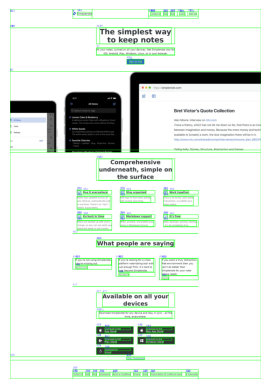

Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\bb\boxed.png


In [33]:
pil_img = loader.image()                                    # WebPImageFile
img_rgb = np.array(pil_img)                                 # RGB
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)          # BGR for OpenCV

# Draw boxes
for b_id, b in bb.items():
    if b is None or b["width"] == 0 or b["height"] == 0:
        continue
    # if not bb_info[b_id]["role_t"] == 'role': continue
    if b_id in ignored_ids:
        continue
    if not b_id in valid_b_ids:
        continue
    color_b = (0, 255, 0)
    color_t = (255, 0, 0)
    # if b_id in {3, 117, 119, 38, 39, 51, 118, 40, 128, 129}: 
    #     color_b = (0, 0, 255)
    #     color_t = (0, 0, 0)

    
    x1, y1 = int(b["x"]), int(b["y"])
    x2 = int(b["x"] + b["width"])
    y2 = int(b["y"] + b["height"])
    
    name = bb_info[b_id]["name"]
    role = bb_info[b_id]["role"]
    text_coordinates = (x1, max(y1 - 8, 0))
    if y1 < 20:
        text_coordinates = (x1, max(y1 + 20, 0))
    # if not bb_info[b_id]["ignored"] and role in allowed_roles:
    
    cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color_b, 2) # Green, width = 2px
    cv2.putText(img_bgr, str(b_id), text_coordinates, cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_t, 1) # Text

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # Back to RGB

# Show
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# Save
out_dir = os.path.join(base_data_path, 'bb')
os.makedirs(out_dir, exist_ok=True)
#out_dir.mkdir(parents=True, exist_ok=True)
out_path = os.path.join(out_dir, "boxed.png")

if not cv2.imwrite(str(out_path), img_bgr):
    raise RuntimeError("error")
print("Image saved in:", out_path)

## Other Bounding Boxes

In [34]:
def get_bb_and_info(filename):
    path = os.path.join(files, filename)
    if not os.path.isdir(path):
        raise FileNotFoundError(f"Dataset page directory not found: {path}")
    loader = PageLoader(path, debug=False)
    if loader.best is None:
        raise RuntimeError(f"No complete screen bundle found in: {path}")
    
    # AXTree
    ax_tree = loader.best.files.get(FileType.AXTree)
    if not ax_tree or 'nodes' not in ax_tree:
        raise RuntimeError(f"AXTree is missing for: {path}")
    nodes = ax_tree['nodes']
    
    # BB
    bb = loader.best.files.get(FileType.BB)
    if not bb:
        raise RuntimeError(f"Bounding boxes are missing for: {path}")
    bb = { int(b_id): b for b_id, b in bb.items() } # turn bb keys to int
    
    # map backendDOMNodeId -> AXTree node
    backend_id_to_axnode = {
        node.get("backendDOMNodeId"): node
        for node in nodes
        if "backendDOMNodeId" in node
    }
    
    bb_info = {}
    for b_id, b in bb.items():
        ax_node = backend_id_to_axnode.get(b_id)
        if not ax_node:
            continue
    
        bb_info[b_id] = {
            "name": ax_node.get("name", {}).get("value", ""),
            # "name_t": ax_node.get("name", {}).get("type", ""),
            "role": ax_node.get("role", {}).get("value", ""),
            # "role_t": ax_node.get("role", {}).get("type", ""),
            "ignored": ax_node.get("ignored", False),
            # "box": b
        }

    # Show
    print(loader.pages.keys())
    print('screen_type:', loader.screen_type, 'page_id:', loader.page_id, 'label:', loader.label)
    plt.imshow(loader.image())
    plt.axis("off")
    plt.show()
    # print(type(loader.best.files[FileType.AXTree]))
    # print(json.dumps(nodes, indent=2, ensure_ascii=False))
    # print(type(bb))
    # for b_id, b in bb.items():
    #     print(b_id, b)
    # print(type(backend_id_to_axnode), json.dumps(backend_id_to_axnode, indent=2, ensure_ascii=False))
    # print(type(bb_info),'\n', json.dumps(bb_info, indent=2, ensure_ascii=False))

    return bb, bb_info, loader.image()

In [35]:
def boxed_image(pil_img, bb, bb_info, out_dir, p_name = ''):
    img_rgb = np.array(pil_img)                                 # RGB
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)          # BGR for OpenCV
    
    # Draw boxes
    for b_id, b in bb.items():
        if b is None or b["width"] == 0 or b["height"] == 0:
            continue
            
        color_b = (0, 255, 0)
        color_t = (255, 0, 0)
        
        x1, y1 = int(b["x"]), int(b["y"])
        x2 = int(b["x"] + b["width"])
        y2 = int(b["y"] + b["height"])
        
        name = bb_info[b_id]["name"]
        role = bb_info[b_id]["role"]
        
        text_coordinates = (x1, max(y1 - 8, 0))
        if y1 < 20:
            text_coordinates = (x1, max(y1 + 20, 0))
            
        if str(role) == p_name:
            cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color_b, 2) # Green, width = 2px
            cv2.putText(img_bgr, str(b_id), text_coordinates, cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_t, 1) # Text
    
    cv2.putText(img_bgr, p_name, (10, 150), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2) # Text

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # Back to RGB
    
    # Show
    # plt.imshow(img_rgb)
    # plt.axis("off")
    # plt.show()

    # Save
    os.makedirs(out_dir, exist_ok=True)
    # out_dir.mkdir(parents=True, exist_ok=True)
    out_path = os.path.join(out_dir, f"boxed_{p_name}.png")
    
    if not cv2.imwrite(str(out_path), img_bgr):
        raise RuntimeError("error")
    print(f"Role:{p_name}. Image saved in:", out_path)

Requested sites not found in balanced_7k; using fallback sample: ['1655885112781', '1655886032342', '1655886594268']
dict_keys(['default_1280-720', 'iPhone-13 Pro', 'default_1536-864', 'iPad-Pro', 'default_1920-1080', 'default_1366-768'])
screen_type: default_1920-1080 page_id: 1655885112781 label: tutorial


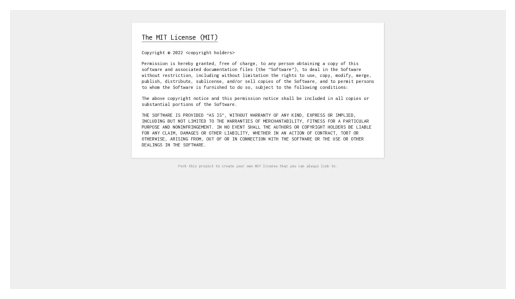

{'none', 'contentinfo', 'RootWebArea', 'StaticText', 'article', 'link', 'heading', 'paragraph'}
Role:none. Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\bb\1655885112781\boxed_none.png
Role:contentinfo. Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\bb\1655885112781\boxed_contentinfo.png
Role:RootWebArea. Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\bb\1655885112781\boxed_RootWebArea.png
Role:StaticText. Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\bb\1655885112781\boxed_StaticText.png
Role:article. Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12

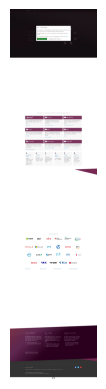

{'menu', 'menuitem', 'list', 'RootWebArea', 'generic', 'blockquote', 'separator', 'button', 'StaticText', 'dialog', 'paragraph', 'listitem', 'banner', 'navigation', 'contentinfo', 'heading', 'img', 'none', 'LineBreak', 'link'}
Role:menu. Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\bb\1655886032342\boxed_menu.png
Role:menuitem. Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\bb\1655886032342\boxed_menuitem.png
Role:list. Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\bb\1655886032342\boxed_list.png
Role:RootWebArea. Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\bb\1655886032342\boxed_RootWebArea.png
Rol

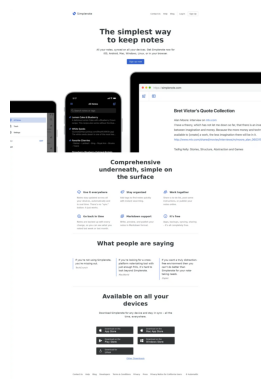

{'list', 'RootWebArea', 'generic', 'blockquote', 'separator', 'main', 'StaticText', 'paragraph', 'listitem', 'navigation', 'banner', 'figure', 'contentinfo', 'heading', 'img', 'Section', 'none', 'link', 'article'}
Role:list. Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\bb\1655886594268\boxed_list.png
Role:RootWebArea. Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\bb\1655886594268\boxed_RootWebArea.png
Role:generic. Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\bb\1655886594268\boxed_generic.png
Role:blockquote. Image saved in: C:\Users\70133\.cache\huggingface\hub\datasets--biglab--webui-7kbal\snapshots\2312ad12c6df0715fd808a934cc37ada255517b5\dataset1\bb\1655886594268\boxed_blockquote.png
Role:s

In [36]:
# Rebind helper here too so rerunning only this cell fixes an older kernel state.
def get_bb_and_info_current(filename):
    path = os.path.join(files, filename)
    if not os.path.isdir(path):
        raise FileNotFoundError(f"Dataset page directory not found: {path}")
    loader = PageLoader(path, debug=False)
    if loader.best is None:
        raise RuntimeError(f"No complete screen bundle found in: {path}")

    ax_tree = loader.best.files.get(FileType.AXTree)
    if not ax_tree or 'nodes' not in ax_tree:
        raise RuntimeError(f"AXTree is missing for: {path}")
    nodes = ax_tree['nodes']

    bb = loader.best.files.get(FileType.BB)
    if not bb:
        raise RuntimeError(f"Bounding boxes are missing for: {path}")
    bb = {int(b_id): b for b_id, b in bb.items()}

    backend_id_to_axnode = {
        node.get("backendDOMNodeId"): node
        for node in nodes
        if "backendDOMNodeId" in node
    }

    bb_info = {}
    for b_id, b in bb.items():
        ax_node = backend_id_to_axnode.get(b_id)
        if not ax_node:
            continue
        bb_info[b_id] = {
            "name": ax_node.get("name", {}).get("value", ""),
            "role": ax_node.get("role", {}).get("value", ""),
            "ignored": ax_node.get("ignored", False),
        }

    print(loader.pages.keys())
    print('screen_type:', loader.screen_type, 'page_id:', loader.page_id, 'label:', loader.label)
    plt.imshow(loader.image())
    plt.axis("off")
    plt.show()
    return bb, bb_info, loader.image()

get_bb_and_info = get_bb_and_info_current

requested_sites = ['1655885631145', '1655888953458', '1655890112189']
available_sites = sorted([site for site in requested_sites if os.path.isdir(os.path.join(files, site))])
if not available_sites:
    available_sites = sorted(os.listdir(files))[:3]
    print(f"Requested sites not found in {dataset_dir}; using fallback sample: {available_sites}")

for site in available_sites:
    bb1, bb_info1, img = get_bb_and_info(site)
    
    allowed_roles1 = {info["role"] for info in bb_info1.values()}
    print(allowed_roles1)
    
    out_dir1 = os.path.join(base_data_path, 'bb', site)
    
    for role in allowed_roles1:
        boxed_image(img, bb1, bb_info1, out_dir1, role)

In [37]:
roles_unic = {'complementary', 'figure', 'button', 'tab', 'none', 'LayoutTableCell', 'tablist', 'article', 'IframePresentational',
              'Legend', 'navigation', 'gridcell', 'Section', 'spinbutton', 'DisclosureTriangle', 'img', 'DescriptionList', 'searchbox',
              'RootWebArea', 'group', 'Figcaption', 'row', 'Iframe', 'combobox', 'Pre', 'heading', 'menubar', 'DescriptionListDetail', 'menu',
              'separator', 'region', 'LineBreak', 'HeaderAsNonLandmark', 'columnheader', 'emphasis', 'listbox', 'rowheader', 'form', 'option',
              'textbox', 'link', 'LabelText', 'MenuListPopup', 'contentinfo', 'alertdialog', 'FooterAsNonLandmark', 'dialog', 'paragraph',
              'status', 'ListMarker', 'main', 'switch', 'Video', 'Abbr', 'tabpanel', 'grid', 'time', 'table', 'StaticText', 'listitem',
              'DescriptionListTerm', 'insertion', 'PluginObject', 'checkbox', 'menuitem', 'superscript', 'generic', 'banner', 'list',
              'LayoutTableRow', 'strong', 'LayoutTable', 'search', 'blockquote', 'Details'}
print(sorted(roles_unic))

['Abbr', 'DescriptionList', 'DescriptionListDetail', 'DescriptionListTerm', 'Details', 'DisclosureTriangle', 'Figcaption', 'FooterAsNonLandmark', 'HeaderAsNonLandmark', 'Iframe', 'IframePresentational', 'LabelText', 'LayoutTable', 'LayoutTableCell', 'LayoutTableRow', 'Legend', 'LineBreak', 'ListMarker', 'MenuListPopup', 'PluginObject', 'Pre', 'RootWebArea', 'Section', 'StaticText', 'Video', 'alertdialog', 'article', 'banner', 'blockquote', 'button', 'checkbox', 'columnheader', 'combobox', 'complementary', 'contentinfo', 'dialog', 'emphasis', 'figure', 'form', 'generic', 'grid', 'gridcell', 'group', 'heading', 'img', 'insertion', 'link', 'list', 'listbox', 'listitem', 'main', 'menu', 'menubar', 'menuitem', 'navigation', 'none', 'option', 'paragraph', 'region', 'row', 'rowheader', 'search', 'searchbox', 'separator', 'spinbutton', 'status', 'strong', 'superscript', 'switch', 'tab', 'table', 'tablist', 'tabpanel', 'textbox', 'time']


## Image viewer

In [38]:
bb_path = os.path.join(d1_path, "bb")

In [39]:
pages = os.listdir(bb_path)
pages

['1655885112781', '1655886032342', '1655886594268', 'boxed.png']

In [40]:
# cur_page = 0
# fpath = os.path.join(bb_path, pages[cur_page])
# print(os.listdir(fpath))

# for fname in os.listdir(fpath):
#     print(fname)
#     #with open(os.path.join(fpath, fname), 'rb') as f:
#     img = Image.open(os.path.join(fpath, fname))
#     _ = plt.imshow(img)
#     _ = plt.axis("off")
#     plt.show()

# Conversion

In [41]:
import importlib, widget_spec
importlib.reload(widget_spec)

<module 'widget_spec' from 'c:\\Users\\70133\\VS_Code_Projects\\jarvis-core\\notebooks\\webui\\widget_spec.py'>

In [42]:
from widget_spec import (
    Widget,
    WidgetType,
    WidgetHint,
    LINK_ROLES,
    MAIN_ROLES,
    role_to_leaf_type,
    role_is_container,
    text_role_to_hints,
)


def _layout_hint(child_bboxes):
    """
    Given the list of child bboxes that actually participated in a block
    (None entries for children without geometry), return VBOX / HBOX / None.

    Rule: look at pairs of adjacent, geometry-bearing children. For each pair
    classify it as vertical (y-ranges disjoint) or horizontal (x-ranges
    disjoint). Majority wins; ties / insufficient signal -> no hint.
    """
    boxes = [b for b in child_bboxes if b and b.get("width", 0) > 0 and b.get("height", 0) > 0]
    if len(boxes) < 2:
        return None
    v = h = 0
    for a, b in zip(boxes, boxes[1:]):
        ax1, ay1 = a["x"], a["y"]
        ax2, ay2 = ax1 + a["width"], ay1 + a["height"]
        bx1, by1 = b["x"], b["y"]
        bx2, by2 = bx1 + b["width"], by1 + b["height"]
        y_gap = by1 >= ay2 or ay1 >= by2
        x_gap = bx1 >= ax2 or ax1 >= bx2
        if y_gap and not x_gap:
            v += 1
        elif x_gap and not y_gap:
            h += 1
        elif y_gap and x_gap:
            # diagonal — pick the larger separation
            if (by1 - ay2) > (bx1 - ax2):
                v += 1
            else:
                h += 1
    if v > h:
        return WidgetHint.VBOX
    if h > v:
        return WidgetHint.HBOX
    return None


def ax_to_widget(node, bb=None) -> [Widget, None]:
    """
    Recursively convert a cleaned AXTree node (as produced by `build_tree` /
    `transform_tree`) into the internal Widget representation.

    Rules are applied bottom-up:
      * leaf roles (StaticText, link, img, ...)   -> leaf widget with `name`
      * container roles wrapping widget children  -> `block` widget
      * single-child transparent wrappers collapse upward
      * `main` / `RootWebArea` adds the `main` hint to the produced widget
      * a `block` with geometry gets a `vbox` or `hbox` hint when its children
        clearly stack along one axis (using `bb` for bounding boxes)

    `bb` is `{backendDOMNodeId: {x, y, width, height}}`; it is consumed here
    and never stored on the Widget.

    Returns None for branches that reduce to nothing (empty containers, empty
    text leaves).
    """
    role = node.get("role", "") or ""
    name = (node.get("name", "") or "").strip()

    child_pairs = []  # (widget, child_bbox) aligned with produced widgets
    for child in node.get("children", []):
        w = ax_to_widget(child, bb)
        if w is not None:
            cb = bb.get(child.get("back_id")) if bb else None
            child_pairs.append((w, cb))
    child_widgets = [w for w, _ in child_pairs]

    leaf_type = role_to_leaf_type(role)

    # Link carrying children stays a link but wraps them.
    if role in LINK_ROLES:
        if not child_widgets and not name:
            return None
        return Widget(
            type=WidgetType.LINK,
            name=name,
            children=child_widgets,
            node_id=node.get("id"),
            back_id=node.get("back_id"),
            role=role,
        )

    # Text roles often wrap a StaticText child with the same accessible name
    # (for example heading -> StaticText). Keep the concrete StaticText node and
    # do not duplicate the parent text. The wrapper role itself is preserved as
    # a hint on the resulting widget (heading -> HEADING/SUBHEADING, strong ->
    # BOLD, emphasis -> ITALIC, blockquote -> QUOTE, etc.) via text_role_to_hints.
    if leaf_type == WidgetType.TEXT and child_widgets:
        promoted = text_role_to_hints(role, node.get("level"))
        if len(child_widgets) == 1:
            result = child_widgets[0]
            for h in promoted:
                result.add_hint(h)
            return result
        result = Widget(
            type=WidgetType.BLOCK,
            children=child_widgets,
            node_id=node.get("id"),
            back_id=node.get("back_id"),
            role=role,
        )
        for h in promoted:
            result.add_hint(h)
        return result

    # Leaf reductions (text / image, and other non-link leaf roles).
    if leaf_type is not None and not child_widgets:
        if leaf_type == WidgetType.TEXT and not name:
            return None
        result = Widget(
            type=leaf_type,
            name=name,
            node_id=node.get("id"),
            back_id=node.get("back_id"),
            role=role,
        )
        for h in text_role_to_hints(role, node.get("level")):
            result.add_hint(h)
        return result

    # No widget children: nothing to wrap.
    if not child_widgets:
        return None

    # Transparent single-child container: bubble the child up, applying hints.
    if len(child_widgets) == 1 and role_is_container(role):
        w = child_widgets[0]
        if role in MAIN_ROLES:
            w.add_hint(WidgetHint.MAIN)
        return w

    w = Widget(
        type=WidgetType.BLOCK,
        name=name,
        children=child_widgets,
        node_id=node.get("id"),
        back_id=node.get("back_id"),
        role=role,
    )
    if role in MAIN_ROLES:
        w.add_hint(WidgetHint.MAIN)
    layout = _layout_hint([cb for _, cb in child_pairs])
    if layout is not None:
        w.add_hint(layout)
    return w

## Filtering: junk subtree removal

1. Build candidates for current loader (`build_candidates_for_loader`)
2. Predict junk/not_junk via trained classifier (lazy-loaded once)
3. Prune subtrees rooted at junk-predicted candidates from `tree`
4. Re-compute `widget_root = ax_to_widget(filtered_tree, bb)`

Кандидаты не сохраняются — используются только в памяти на этой странице.

In [43]:
import sys, os
from pathlib import Path

# Make filter_apply importable from notebooks/webui/training/
_TRAINING_DIR = Path(os.getcwd()) / 'training'
if not _TRAINING_DIR.exists():
    _TRAINING_DIR = Path(os.getcwd()).parent / 'webui' / 'training'
sys.path.insert(0, str(_TRAINING_DIR))

import filter_apply as fa
import build_candidates as bc_mod
import importlib
importlib.reload(fa)

# Lazy-load classifier (cached across cell runs)
if '_FILTER_MODEL' not in globals():
    print('Training filter model (first run, ~10s)...')
    _FILTER_MODEL, _FILTER_ARTIFACTS = fa.train_best_model()
    print('Filter model ready.')

# Build candidates for THIS page (transient, not saved)
DATASET_ROOT = fa.DATASET_ROOT
page_candidates = bc_mod.build_candidates_for_loader(loader, DATASET_ROOT)
print(f'Generated {len(page_candidates)} candidates for page {loader.page_id}')

if page_candidates:
    # Add global_recurrence from precomputed db if available
    GHASH = Path('output') / 'candidate' / 'global_hash_recurrence.json'
    if GHASH.exists():
        import json as _json, hashlib as _h
        with GHASH.open(encoding='utf-8') as _f:
            _gd = _json.load(_f)
        _gcounts, _gtotal = _gd['hash_counts'], _gd['total_pages']
        def _norm(t): return ' '.join((t or '').lower().split())
        for c in page_candidates:
            payload = f"{c.get('role','')}::{_norm(c.get('text_subtree',''))}".encode('utf-8')
            h = _h.md5(payload).hexdigest()[:16]
            c['content_hash'] = h
            c['global_recurrence_count'] = _gcounts.get(h, 0)
            c['global_recurrence_ratio'] = _gcounts.get(h, 0) / max(_gtotal, 1)
            c['recurrence_count'] = 1
    else:
        for c in page_candidates:
            c.setdefault('content_hash', '')
            c.setdefault('global_recurrence_count', 0)
            c.setdefault('global_recurrence_ratio', 0.0)
            c.setdefault('recurrence_count', 1)

    predictions = fa.predict_for_page(page_candidates, _FILTER_MODEL, _FILTER_ARTIFACTS)

    # Match by backend_dom_node_id (stable DOM-level id), fallback to AX node_id
    junk_back_ids = set()
    junk_node_ids = set()
    for p in predictions:
        if p['predicted_junk']:
            cand = p['candidate']
            bid = cand.get('backend_dom_node_id')
            if bid is not None:
                try: junk_back_ids.add(int(bid))
                except (TypeError, ValueError): pass
            nid = cand.get('node_id')
            if nid is not None:
                junk_node_ids.add(str(nid))
    print(f'Predicted junk: {len(junk_back_ids)} candidates')

    # Debug: how many match in tree?
    def _collect(t, ns, bs):
        if not isinstance(t, dict): return
        if t.get('id') is not None: ns.add(str(t['id']))
        if t.get('back_id') is not None:
            try: bs.add(int(t['back_id']))
            except (TypeError, ValueError): pass
        for ch in t.get('children', []): _collect(ch, ns, bs)
    tn, tb = set(), set()
    _collect(tree, tn, tb)
    print(f'  matched by back_id: {len(junk_back_ids & tb)}, by node_id: {len(junk_node_ids & tn)}')

    def _prune(t, jb, jn):
        if t is None: return None
        bid = t.get('back_id')
        nid = t.get('id')
        if bid is not None:
            try:
                if int(bid) in jb: return None
            except (TypeError, ValueError): pass
        if nid is not None and str(nid) in jn:
            return None
        new_children = []
        for ch in t.get('children', []):
            pr = _prune(ch, jb, jn)
            if pr is not None: new_children.append(pr)
        return {**t, 'children': new_children}

    def _count(t):
        if not isinstance(t, dict): return 0
        return 1 + sum(_count(c) for c in t.get('children', []))

    n_before = _count(tree)
    tree = _prune(tree, junk_back_ids, junk_node_ids)
    n_after = _count(tree)
    print(f'Tree nodes: {n_before} -> {n_after} (removed {n_before - n_after}, compression {(n_before-n_after)/max(n_before,1)*100:.1f}%)')
else:
    print('No candidates -- skipping filter step.')


Training filter model (first run, ~10s)...
Loading train features...
X_train shape: (4385, 20031), y_train: junk=1816/4385
Model trained.
Filter model ready.
Generated 13 candidates for page 1655886594268
Predicted junk: 3 candidates
  matched by back_id: 3, by node_id: 3
Tree nodes: 190 -> 137 (removed 53, compression 27.9%)


### Inspect filter decisions

Что было удалено: список junk-predicted candidates + визуальный overlay на screenshot.

Junk predictions: 3 / 13 candidates

role                  conf text_len text preview                                                          
--------------------------------------------------------------------------------------------------------------
navigation            1.00       95 'Main Navigation submenu Contact Us Contact Us Help Help Blog Blog'   
navigation            1.00      239 'Footer Menu Contact Us Contact Us Help Help Blog Blog Developers '   
banner                0.98      117 'Simplenote Simplenote Main Navigation submenu Contact Us Contact '   


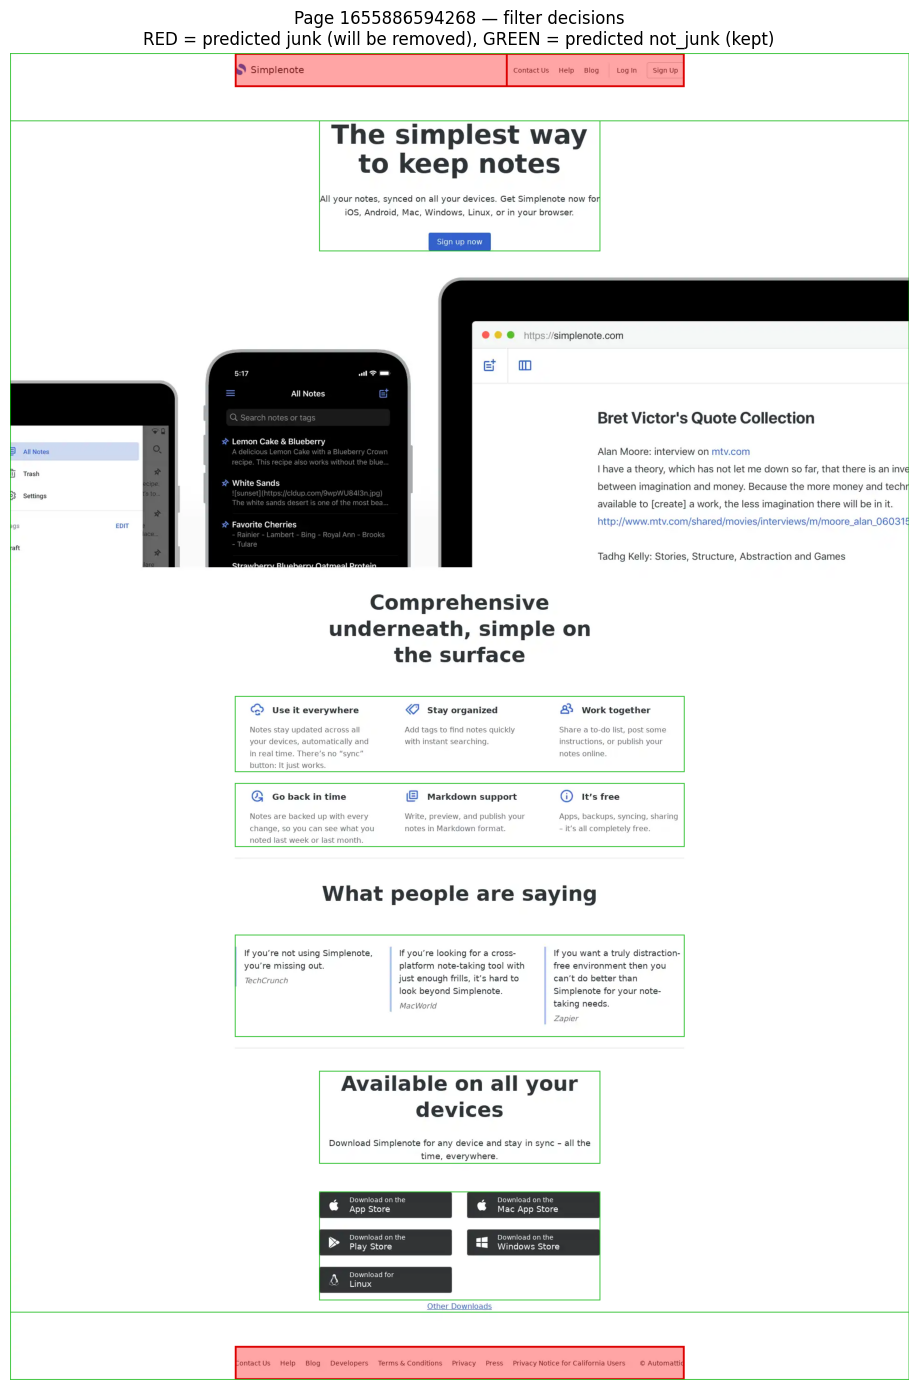

In [44]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

if 'predictions' not in globals() or not predictions:
    print('No predictions in scope — run filter cell first.')
else:
    junk_preds = [p for p in predictions if p['predicted_junk']]
    nj_preds = [p for p in predictions if not p['predicted_junk']]
    print(f'Junk predictions: {len(junk_preds)} / {len(predictions)} candidates\n')

    # === Text table ===
    print(f'{"role":<20s} {"conf":>5s} {"text_len":>8s} {"text preview":<70s}')
    print('-' * 110)
    for p in sorted(junk_preds, key=lambda x: -x['junk_prob']):
        c = p['candidate']
        text = (c.get('text_subtree') or '').replace('\n', ' ')[:65]
        role = c.get('role', '')[:19]
        conf = p.get('junk_prob', 0)
        tlen = c.get('text_len', 0)
        print(f'{role:<20s} {conf:>5.2f} {tlen:>8d} {text!r:<70s}')

    # === Visual overlay ===
    img = loader.image() if hasattr(loader, 'image') and callable(loader.image) else None
    if img is None:
        # Try loading via screenshot path
        from page_loader import FileType
        try:
            img = loader.best.files.get(FileType.ScreenFull)
        except Exception:
            img = None

    if img is not None:
        img_rgb = img.copy().convert('RGB')
        # Draw red shade on junk + green outline on not_junk for context
        from PIL import ImageDraw
        overlay = img_rgb.copy().convert('RGBA')
        layer = Image.new('RGBA', overlay.size, (0, 0, 0, 0))
        draw = ImageDraw.Draw(layer)

        for p in junk_preds:
            bbox = p['candidate'].get('bbox')
            if not bbox: continue
            x = float(bbox.get('x', 0)); y = float(bbox.get('y', 0))
            w = float(bbox.get('width', 0)); h = float(bbox.get('height', 0))
            if w <= 0 or h <= 0: continue
            draw.rectangle([x, y, x+w, y+h], fill=(255, 0, 0, 90))
            draw.rectangle([x, y, x+w, y+h], outline=(220, 0, 0, 255), width=4)

        for p in nj_preds:
            bbox = p['candidate'].get('bbox')
            if not bbox: continue
            x = float(bbox.get('x', 0)); y = float(bbox.get('y', 0))
            w = float(bbox.get('width', 0)); h = float(bbox.get('height', 0))
            if w <= 0 or h <= 0: continue
            draw.rectangle([x, y, x+w, y+h], outline=(0, 180, 0, 200), width=2)

        result = Image.alpha_composite(overlay, layer).convert('RGB')

        fig, ax = plt.subplots(1, 1, figsize=(14, 14))
        ax.imshow(result)
        ax.set_title(f'Page {loader.page_id} — filter decisions\nRED = predicted junk (will be removed), GREEN = predicted not_junk (kept)')
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print('Screenshot not available for visual overlay.')


In [45]:
# bs4 4.14 sometimes does not auto-register the lxml HTML builder, even when
# lxml is installed. Without this, BeautifulSoup(html, "lxml") used inside
# axtree_html_mapper would raise FeatureNotFound. Register manually, with XML
# FIRST (sinks to back of feature list) and HTML SECOND (rises to front;
# wins on lookup("lxml")). Reverse order picks the XML builder for HTML pages
# and triggers a confusing GuessedAtParserWarning at parse time.
import bs4
import bs4.builder
import bs4.builder._lxml as _bs4_lxml
bs4.builder.builder_registry.register(_bs4_lxml.LXMLTreeBuilderForXML)
bs4.builder.builder_registry.register(_bs4_lxml.LXMLTreeBuilder)

from axtree_html_mapper import (
    map_axtree_links_to_html_hrefs_v2,
    apply_link_hrefs_to_tree,
)

if "tree" not in globals():
    nodes_by_id = {node["nodeId"]: node for node in nodes}
    root_node = next(
        node for node in nodes
        if "parentId" not in node or node["parentId"] is None
    )
    tree = build_tree(root_node)
    if "transform_tree" in globals():
        tree = transform_tree(tree)

# Glue HTML hrefs into link-role tree nodes by overwriting their `name` with
# the resolved URL. The original visible text is preserved on `node["orig_name"]`
# and also remains as the link's StaticText children. Links that cannot be
# matched safely (ambiguous, missing in HTML, no text on the AX side) get
# the literal "[LINK]" as their name. The downstream Widget.LINK.name then
# carries the URL, and widget_html.render_widget collapses LINK + single
# text/image child into one <a href=URL>visible text</a> at render time.
link_mapping = map_axtree_links_to_html_hrefs_v2(
    axtree=loader.best.files[FileType.AXTree],
    html=loader.best.files[FileType.HTML],
    base_url=loader.best.files[FileType.URL].strip(),
    parser="lxml",
)
link_counters = apply_link_hrefs_to_tree(tree, link_mapping, fallback="[LINK]")
print(f"Link substitution: {link_counters}")

widget_root = ax_to_widget(tree, bb)
if widget_root is not None:
    print(widget_root.pretty())
else:
    print("AXTree reduced to empty widget tree")


Link substitution: {'with_href': 8, 'with_fallback': 0, 'total_link_nodes': 8}
[block](main) role='generic' name=''
  [block](hbox) role='generic' name=''
    [link](-) role='link' name='https://simplenote.com#content'
      [text](-) role='StaticText' name='Skip to content'
    [block](main,vbox) role='none' name=''
      [block](vbox) role='none' name=''
        [text](heading) role='StaticText' name='The simplest way to keep notes'
        [text](-) role='StaticText' name='All your notes, synced on all your devices. Get Simplenote now for iOS, Android, Mac, Windows, Linux, or in your browser.'
        [link](-) role='link' name='https://app.simplenote.com/signup/'
          [text](-) role='StaticText' name='Sign up now'
      [text](subheading) role='StaticText' name='Comprehensive underneath, simple on the surface'
      [block](hbox) role='none' name=''
        [block](vbox) role='none' name=''
          [image](-) role='figure' name=''
          [text](subheading) role='StaticTex

In [46]:
import importlib, widget_html
importlib.reload(widget_html)
from widget_html import save_document

import inspect
src = inspect.getsource(widget_html.render_widget)
# В новой версии есть универсальный коллапс по all(c.type in TEXT, IMAGE)
assert "all(c.type in" in src, "widget_html ещё старый! kernel закэшировал."
assert "inline" not in src, "ещё старая версия с inline-классом"
print("OK: widget_html обновлён, универсальный коллапс на месте")

OK: widget_html обновлён, универсальный коллапс на месте


In [47]:
from widget_html import save_document

if widget_root is not None:
    os.makedirs("renderer_output", exist_ok=True)
    out_html = os.path.join("renderer_output", f'widget_{loader.page_id}.html')
    #os.makedirs(os.path.dirname(out_html), exist_ok=True)
    save_document(widget_root, out_html, title=f"page {loader.page_id}")
    print("Widget HTML saved in:", out_html)

Widget HTML saved in: renderer_output\widget_1655886594268.html


In [48]:
def count_ax_nodes(ax_tree_or_nodes):
    """Count raw AXTree nodes from either a node list or {'nodes': [...]} dict."""
    if isinstance(ax_tree_or_nodes, list):
        return len(ax_tree_or_nodes)
    if isinstance(ax_tree_or_nodes, dict) and isinstance(ax_tree_or_nodes.get("nodes"), list):
        return len(ax_tree_or_nodes["nodes"])
    return count_tree_nodes(ax_tree_or_nodes)


def count_tree_nodes(node):
    """Count nodes in the nested dict tree produced by build_tree/transform_tree."""
    if not isinstance(node, dict):
        return 0
    return 1 + sum(count_tree_nodes(child) for child in node.get("children", []))


def count_widget_nodes(widget):
    """Count nodes in the Widget tree produced by ax_to_widget."""
    if widget is None:
        return 0
    return 1 + sum(count_widget_nodes(child) for child in widget.children)


def print_compactness_report(raw_ax, clean_tree, widget_root):
    raw_ax_count = count_ax_nodes(raw_ax)
    clean_tree_count = count_tree_nodes(clean_tree)
    widget_count = count_widget_nodes(widget_root)

    def compression(before, after):
        return before / after if after else float("inf")

    def reduction(before, after):
        return (1 - after / before) * 100 if before else 0.0

    print("Compactness report")
    print(f"Raw AXTree nodes:     {raw_ax_count}")
    print(f"Clean AXTree nodes:   {clean_tree_count}")
    print(f"Widget nodes:         {widget_count}")
    print()
    print(f"Raw AXTree -> Widget compression:   {compression(raw_ax_count, widget_count):.2f}x")
    print(f"Raw AXTree -> Widget reduction:      {reduction(raw_ax_count, widget_count):.1f}%")
    print(f"Clean AXTree -> Widget compression: {compression(clean_tree_count, widget_count):.2f}x")
    print(f"Clean AXTree -> Widget reduction:    {reduction(clean_tree_count, widget_count):.1f}%")


print_compactness_report(nodes, tree, widget_root)


Compactness report
Raw AXTree nodes:     508
Clean AXTree nodes:   137
Widget nodes:         72

Raw AXTree -> Widget compression:   7.06x
Raw AXTree -> Widget reduction:      85.8%
Clean AXTree -> Widget compression: 1.90x
Clean AXTree -> Widget reduction:    47.4%


## Copression test

In [49]:
def list_page_dirs(limit=None):
    page_dirs = []
    for name in sorted(os.listdir(files)):
        path = os.path.join(files, name)
        if os.path.isdir(path):
            page_dirs.append(path)
    return page_dirs[:limit] if limit is not None else page_dirs


def select_page_dirs(n, mode="first", seed=42):
    page_dirs = list_page_dirs()
    n = min(n, len(page_dirs))
    if mode == "first":
        return page_dirs[:n]
    if mode == "random":
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(page_dirs), size=n, replace=False)
        return [page_dirs[i] for i in idx]
    raise ValueError("mode must be 'first' or 'random'")


def compactness_metrics(raw_ax_count, clean_tree_count, widget_count):
    def compression(before, after):
        if not after:
            return np.nan
        return before / after

    def reduction(before, after):
        if not before or not after:
            return np.nan
        return (1 - after / before) * 100

    return {
        "raw_to_widget_compression": compression(raw_ax_count, widget_count),
        "raw_to_widget_reduction_pct": reduction(raw_ax_count, widget_count),
        "clean_to_widget_compression": compression(clean_tree_count, widget_count),
        "clean_to_widget_reduction_pct": reduction(clean_tree_count, widget_count),
    }


def widget_to_dict(widget):
    if widget is None:
        return None

    return {
        "type": str(widget.type),
        "hints": sorted(str(hint) for hint in widget.hints),
        "name": widget.name,
        "node_id": widget.node_id,
        "back_id": widget.back_id,
        "role": widget.role,
        "children": [widget_to_dict(child) for child in widget.children],
    }


def save_widget_json(widget_root, page_id, output_dir=os.path.join("output", "widget")):
    if widget_root is None:
        return None

    os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, f"widget_{page_id}.json")
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(widget_to_dict(widget_root), f, ensure_ascii=False, indent=2)
    return out_path


def analyze_page_compactness(page_dir, save_widgets=True, widget_output_dir=os.path.join("output", "widget")):
    global nodes_by_id, valid_b_ids, mod_count, mod_name_count

    page_loader = PageLoader(page_dir, debug=False)
    if page_loader.best is None:
        raise RuntimeError("No complete screen bundle found")

    ax_tree = page_loader.best.files.get(FileType.AXTree)
    if not ax_tree or "nodes" not in ax_tree:
        raise RuntimeError("AXTree is missing")

    page_nodes = ax_tree["nodes"]
    page_bb = page_loader.best.files.get(FileType.BB)
    if not page_bb:
        page_bb = {}
    page_bb = {int(b_id): b for b_id, b in page_bb.items()}

    nodes_by_id = {node["nodeId"]: node for node in page_nodes}
    root_node = next(
        node for node in page_nodes
        if "parentId" not in node or node["parentId"] is None
    )

    valid_b_ids = []
    mod_count = 0
    mod_name_count = 0

    raw_tree = build_tree(root_node)
    clean_tree = transform_tree(raw_tree)
    page_widget_root = ax_to_widget(clean_tree, page_bb)
    widget_path = save_widget_json(
        page_widget_root,
        page_loader.page_id,
        output_dir=widget_output_dir,
    ) if save_widgets else None

    raw_ax_count = count_ax_nodes(page_nodes)
    clean_tree_count = count_tree_nodes(clean_tree)
    widget_count = count_widget_nodes(page_widget_root)

    return {
        "page_id": os.path.basename(page_dir),
        "screen_type": page_loader.screen_type,
        "raw_ax_nodes": raw_ax_count,
        "clean_ax_nodes": clean_tree_count,
        "widget_nodes": widget_count,
        "widget_empty": page_widget_root is None,
        "widget_path": widget_path,
        **compactness_metrics(raw_ax_count, clean_tree_count, widget_count),
    }


def run_compression_test(n=20, mode="first", seed=42, save_widgets=True, widget_output_dir=os.path.join("output", "widget")):
    rows = []
    errors = []

    for page_dir in select_page_dirs(n, mode=mode, seed=seed):
        try:
            rows.append(analyze_page_compactness(
                page_dir,
                save_widgets=save_widgets,
                widget_output_dir=widget_output_dir,
            ))
        except Exception as exc:
            errors.append({
                "page_id": os.path.basename(page_dir),
                "error": str(exc),
            })

    df = pd.DataFrame(rows)
    err_df = pd.DataFrame(errors)

    print(f"Compression test: mode={mode!r}, requested={n}, ok={len(df)}, errors={len(err_df)}")
    if save_widgets:
        print("Widget JSON output:", widget_output_dir)
    if not df.empty:
        display(df)
        empty_df = df[df["widget_empty"]]
        if not empty_df.empty:
            print("Empty widget pages:", len(empty_df))
            display(empty_df[["page_id", "screen_type", "raw_ax_nodes", "clean_ax_nodes", "widget_nodes"]])

        summary_cols = [
            "raw_ax_nodes",
            "clean_ax_nodes",
            "widget_nodes",
            "raw_to_widget_compression",
            "raw_to_widget_reduction_pct",
            "clean_to_widget_compression",
            "clean_to_widget_reduction_pct",
        ]
        display(df[summary_cols].agg(["mean", "median", "min", "max"]))
    if not err_df.empty:
        display(err_df)

    return df, err_df


# Modes:
first_results, first_errors = run_compression_test(n=1, mode="first", save_widgets=False)
# random_results, random_errors = run_compression_test(n=20, mode="random", seed=42)


Compression test: mode='first', requested=1, ok=1, errors=0


,page_id,screen_type,raw_ax_nodes,clean_ax_nodes,widget_nodes,widget_empty,widget_path,raw_to_widget_compression,raw_to_widget_reduction_pct,clean_to_widget_compression,clean_to_widget_reduction_pct
0,1655885112781,default_1920-1080,18,18,9,False,None,2.0,50.0,2.0,50.0


,raw_ax_nodes,clean_ax_nodes,widget_nodes,raw_to_widget_compression,raw_to_widget_reduction_pct,clean_to_widget_compression,clean_to_widget_reduction_pct
mean,18.0,18.0,9.0,2.0,50.0,2.0,50.0
median,18.0,18.0,9.0,2.0,50.0,2.0,50.0
min,18.0,18.0,9.0,2.0,50.0,2.0,50.0
max,18.0,18.0,9.0,2.0,50.0,2.0,50.0


# Pipeline report artifacts

Generate report-ready artifacts for a selected page: raw AXTree overlay, filtered AXTree overlay, Widget JSON, Widget HTML, and a side-by-side report HTML.


In [50]:
from PIL import ImageDraw, ImageFont
from html import escape

from axtree_html_mapper import (
    map_axtree_links_to_html_hrefs_v2,
    apply_link_hrefs_to_tree,
)


def _collect_tree_back_ids(node):
    if not isinstance(node, dict):
        return set()
    ids = set()
    back_id = node.get("back_id")
    if back_id is not None:
        ids.add(back_id)
    for child in node.get("children", []):
        ids.update(_collect_tree_back_ids(child))
    return ids


def _role_color(role, ignored=False):
    if ignored:
        return (150, 150, 150, 170)
    palette = {
        "RootWebArea": (220, 40, 40, 220),
        "main": (220, 40, 40, 220),
        "link": (30, 110, 230, 220),
        "StaticText": (20, 150, 80, 220),
        "paragraph": (20, 150, 80, 220),
        "heading": (180, 90, 220, 220),
        "button": (245, 145, 30, 220),
        "textbox": (245, 145, 30, 220),
        "img": (35, 165, 180, 220),
        "image": (35, 165, 180, 220),
    }
    return palette.get(role, (255, 200, 40, 210))


def _bbox_is_valid(box):
    return (
        isinstance(box, dict)
        and float(box.get("width", 0) or 0) > 0
        and float(box.get("height", 0) or 0) > 0
    )


def _draw_axtree_overlay(
    pil_img,
    bb,
    bb_info,
    out_path,
    title="AXTree overlay",
    include_ids=None,
    draw_ignored=True,
    max_labels=120,
    min_area=12,
):
    img = pil_img.convert("RGBA")
    overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    font = ImageFont.load_default()

    items = []
    for b_id, box in bb.items():
        if include_ids is not None and b_id not in include_ids:
            continue
        if not _bbox_is_valid(box):
            continue
        info = bb_info.get(b_id, {})
        if info.get("ignored", False) and not draw_ignored:
            continue
        area = float(box["width"]) * float(box["height"])
        if area < min_area:
            continue
        items.append((area, b_id, box, info))

    items.sort(reverse=True, key=lambda x: x[0])

    for _, b_id, box, info in items:
        x1 = int(float(box["x"]))
        y1 = int(float(box["y"]))
        x2 = int(float(box["x"]) + float(box["width"]))
        y2 = int(float(box["y"]) + float(box["height"]))
        role = info.get("role", "")
        color = _role_color(role, ignored=info.get("ignored", False))
        draw.rectangle((x1, y1, x2, y2), outline=color, width=2)

    labeled = 0
    for _, b_id, box, info in sorted(items, key=lambda x: x[0]):
        if labeled >= max_labels:
            break
        role = info.get("role", "")
        name = (info.get("name", "") or "").strip()
        if not role and not name:
            continue

        x1 = int(float(box["x"]))
        y1 = int(float(box["y"]))
        label = f"{b_id} {role}"
        if name:
            label = f"{label}: {name[:30]}"

        color = _role_color(role, ignored=info.get("ignored", False))
        tx, ty = x1, max(y1 - 12, 0)
        tw = max(50, min(len(label) * 6 + 6, img.size[0] - tx))
        draw.rectangle((tx, ty, tx + tw, ty + 11), fill=(255, 255, 255, 210))
        draw.text((tx + 2, ty), label, fill=color[:3] + (255,), font=font)
        labeled += 1

    img = Image.alpha_composite(img, overlay).convert("RGB")

    strip_h = 28
    titled = Image.new("RGB", (img.size[0], img.size[1] + strip_h), "white")
    titled.paste(img, (0, strip_h))
    title_draw = ImageDraw.Draw(titled)
    title_draw.text((8, 8), f"{title} | boxes={len(items)}", fill=(0, 0, 0), font=font)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    titled.save(out_path)
    return out_path, len(items)


def _build_page_trees_for_report(page_loader):
    page_nodes = page_loader.best.files[FileType.AXTree]["nodes"]
    page_bb = page_loader.best.files.get(FileType.BB) or {}
    page_bb = {int(b_id): b for b_id, b in page_bb.items()}

    page_nodes_by_id = {node["nodeId"]: node for node in page_nodes}
    root_node = next(
        node for node in page_nodes
        if "parentId" not in node or node["parentId"] is None
    )

    old_nodes_by_id = globals().get("nodes_by_id")
    try:
        globals()["nodes_by_id"] = page_nodes_by_id
        raw_tree = build_tree(root_node)
        clean_tree = transform_tree(raw_tree)
    finally:
        if old_nodes_by_id is None:
            globals().pop("nodes_by_id", None)
        else:
            globals()["nodes_by_id"] = old_nodes_by_id

    # Glue resolved hrefs into link-role tree nodes so the downstream Widget
    # carries URLs in LINK.name (and unmatchable links get "[LINK]"). Matches
    # what cell 48 does for the single-page conversion.
    page_html_text = page_loader.best.files.get(FileType.HTML, "") or ""
    page_url = (page_loader.best.files.get(FileType.URL, "") or "").strip()
    link_mapping = map_axtree_links_to_html_hrefs_v2(
        axtree=page_loader.best.files[FileType.AXTree],
        html=page_html_text,
        base_url=page_url,
        parser="lxml",
    )
    apply_link_hrefs_to_tree(clean_tree, link_mapping, fallback="[LINK]")

    widget_root = ax_to_widget(clean_tree, page_bb)
    return page_nodes, page_bb, raw_tree, clean_tree, widget_root


def _build_bb_info(page_nodes, bb):
    backend_id_to_axnode = {
        node.get("backendDOMNodeId"): node
        for node in page_nodes
        if "backendDOMNodeId" in node
    }
    bb_info = {}
    for b_id, box in bb.items():
        ax_node = backend_id_to_axnode.get(b_id)
        if not ax_node:
            continue
        bb_info[b_id] = {
            "name": ax_node.get("name", {}).get("value", ""),
            "role": ax_node.get("role", {}).get("value", ""),
            "ignored": ax_node.get("ignored", False),
            "box": box,
        }
    return bb_info


def _render_html_to_png(html_path, png_path, viewport_width=1400, viewport_height=1800):
    """Render saved widget HTML into a PNG screenshot for report composition.

    Run Playwright in a separate Python process because Jupyter already owns an
    asyncio loop, and Playwright's sync API cannot run inside that loop.
    """
    import subprocess
    import sys

    html_uri = Path(html_path).resolve().as_uri()
    png_path = str(Path(png_path))
    render_code = r'''
import sys
from playwright.sync_api import sync_playwright

html_uri = sys.argv[1]
png_path = sys.argv[2]
viewport_width = int(sys.argv[3])
viewport_height = int(sys.argv[4])

with sync_playwright() as p:
    browser = p.chromium.launch()
    page = browser.new_page(viewport={"width": viewport_width, "height": viewport_height})
    page.goto(html_uri, wait_until="networkidle")
    page.screenshot(path=png_path, full_page=True)
    browser.close()
'''

    try:
        result = subprocess.run(
            [
                sys.executable,
                "-c",
                render_code,
                html_uri,
                png_path,
                str(viewport_width),
                str(viewport_height),
            ],
            capture_output=True,
            text=True,
            timeout=60,
        )
    except Exception as exc:
        error = str(exc)
        print(f"Widget render PNG skipped: {error}")
        return None, error

    if result.returncode != 0:
        error = (result.stderr or result.stdout or "unknown Playwright render error").strip()
        print(f"Widget render PNG skipped: {error}")
        return None, error

    if not Path(png_path).exists():
        error = "Playwright finished without creating PNG"
        print(f"Widget render PNG skipped: {error}")
        return None, error

    return png_path, None


def make_pipeline_report_artifacts(
    page_id,
    output_dir=os.path.join("output", "pipeline_report"),
    draw_ignored_raw=True,
    draw_ignored_filtered=False,
    max_labels=120,
):
    """Create report artifacts for one page_id.

    Outputs:
      - raw_axtree_overlay.png
      - filtered_axtree_overlay.png
      - widget.json, if widget is not empty
      - widget.html, if widget is not empty
      - widget_render.png, if widget HTML can be rendered by Playwright
      - index.html with a side-by-side composition
    """
    page_id = str(page_id)
    page_dir = os.path.join(files, page_id)
    if not os.path.isdir(page_dir):
        raise FileNotFoundError(f"Page directory not found: {page_dir}")

    page_loader = PageLoader(page_dir, debug=False)
    if page_loader.best is None:
        raise RuntimeError(f"No complete screen bundle found for page {page_id}")

    page_nodes, page_bb, raw_tree, clean_tree, widget_root = _build_page_trees_for_report(page_loader)
    bb_info = _build_bb_info(page_nodes, page_bb)
    pil_img = page_loader.image()
    if pil_img is None:
        raise RuntimeError(f"No screenshot found for page {page_id}")

    page_out_dir = os.path.join(output_dir, page_id)
    os.makedirs(page_out_dir, exist_ok=True)

    raw_overlay_path, raw_boxes = _draw_axtree_overlay(
        pil_img,
        page_bb,
        bb_info,
        os.path.join(page_out_dir, "raw_axtree_overlay.png"),
        title=f"Raw AXTree | page {page_id}",
        include_ids=None,
        draw_ignored=draw_ignored_raw,
        max_labels=max_labels,
    )

    clean_back_ids = _collect_tree_back_ids(clean_tree)
    filtered_overlay_path, filtered_boxes = _draw_axtree_overlay(
        pil_img,
        page_bb,
        bb_info,
        os.path.join(page_out_dir, "filtered_axtree_overlay.png"),
        title=f"Filtered AXTree | page {page_id}",
        include_ids=clean_back_ids,
        draw_ignored=draw_ignored_filtered,
        max_labels=max_labels,
    )

    widget_json_path = save_widget_json(widget_root, page_id, output_dir=page_out_dir)

    widget_html_path = None
    if widget_root is not None:
        from widget_html import save_document
        widget_html_path = os.path.join(page_out_dir, "widget.html")
        save_document(widget_root, widget_html_path, title=f"Widget page {page_id}")

    widget_render_path = None
    widget_render_error = None
    if widget_html_path is not None:
        widget_render_path, widget_render_error = _render_html_to_png(
            widget_html_path,
            os.path.join(page_out_dir, "widget_render.png"),
        )

    report_path = os.path.join(page_out_dir, "index.html")
    raw_rel = os.path.basename(raw_overlay_path)
    filtered_rel = os.path.basename(filtered_overlay_path)
    widget_rel = os.path.basename(widget_html_path) if widget_html_path else None
    widget_render_rel = os.path.basename(widget_render_path) if widget_render_path else None

    if widget_render_rel:
        widget_panel = f'<img src="{escape(widget_render_rel)}">'
    elif widget_rel:
        widget_panel = (
            f'<iframe src="{escape(widget_rel)}"></iframe>'
            '<p class="fallback-link">Widget render PNG was not created; showing HTML iframe fallback.</p>'
        )
    else:
        widget_panel = '<div class="empty">Widget tree is empty for this page.</div>'

    report_html = f"""<!doctype html>
<html>
<head>
<meta charset="utf-8">
<title>Pipeline report {escape(page_id)}</title>
<style>
body {{ font-family: sans-serif; margin: 16px; background: #f6f6f6; color: #111; }}
h1 {{ font-size: 18px; margin: 0 0 12px; }}
.meta {{ margin-bottom: 12px; color: #444; font-size: 13px; }}
.grid {{ display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 12px; align-items: start; }}
.panel {{ background: white; border: 1px solid #ddd; border-radius: 6px; padding: 8px; min-width: 0; }}
.panel h2 {{ font-size: 14px; margin: 0 0 8px; }}
.panel img {{ width: 100%; height: auto; display: block; }}
.panel iframe {{ width: 100%; height: 80vh; border: 1px solid #ccc; background: white; }}
.fallback-link {{ margin: 8px 0 0; color: #777; font-size: 12px; }}
.empty {{ padding: 24px; border: 1px dashed #bbb; color: #555; }}
</style>
</head>
<body>
<h1>AXTree -> Widget -> HTML | page {escape(page_id)}</h1>
<div class="meta">
Screen: {escape(page_loader.screen_type)} | Raw nodes: {len(page_nodes)} | Clean nodes: {count_tree_nodes(clean_tree)} | Widget nodes: {count_widget_nodes(widget_root)} | Raw boxes: {raw_boxes} | Filtered boxes: {filtered_boxes}
</div>
<div class="grid">
  <section class="panel"><h2>Raw AXTree over screenshot</h2><img src="{escape(raw_rel)}"></section>
  <section class="panel"><h2>Filtered AXTree over screenshot</h2><img src="{escape(filtered_rel)}"></section>
  <section class="panel"><h2>Widget HTML</h2>{widget_panel}</section>
</div>
</body>
</html>"""

    with open(report_path, "w", encoding="utf-8") as f:
        f.write(report_html)

    result = {
        "page_id": page_id,
        "screen_type": page_loader.screen_type,
        "output_dir": page_out_dir,
        "report_path": report_path,
        "raw_overlay_path": raw_overlay_path,
        "filtered_overlay_path": filtered_overlay_path,
        "widget_json_path": widget_json_path,
        "widget_html_path": widget_html_path,
        "widget_render_path": widget_render_path,
        "widget_render_error": widget_render_error,
        "raw_ax_nodes": len(page_nodes),
        "clean_ax_nodes": count_tree_nodes(clean_tree),
        "widget_nodes": count_widget_nodes(widget_root),
        "raw_boxes": raw_boxes,
        "filtered_boxes": filtered_boxes,
        "widget_empty": widget_root is None,
    }
    print(json.dumps(result, ensure_ascii=False, indent=2))
    return result


def score_pipeline_report_candidates(n=200, mode="first", seed=42):
    """Rank pages that are likely to look good in the report visualization."""
    rows = []
    errors = []
    for page_dir in select_page_dirs(n, mode=mode, seed=seed):
        try:
            page_loader = PageLoader(page_dir, debug=False)
            page_nodes, page_bb, raw_tree, clean_tree, widget_root = _build_page_trees_for_report(page_loader)
            raw_count = len(page_nodes)
            clean_count = count_tree_nodes(clean_tree)
            widget_count = count_widget_nodes(widget_root)
            bb_count = sum(1 for box in page_bb.values() if _bbox_is_valid(box))
            clean_back_ids = _collect_tree_back_ids(clean_tree)
            filtered_bb_count = sum(
                1 for b_id, box in page_bb.items()
                if b_id in clean_back_ids and _bbox_is_valid(box)
            )
            rows.append({
                "page_id": os.path.basename(page_dir),
                "screen_type": page_loader.screen_type,
                "raw_ax_nodes": raw_count,
                "clean_ax_nodes": clean_count,
                "widget_nodes": widget_count,
                "raw_boxes": bb_count,
                "filtered_boxes": filtered_bb_count,
                "raw_to_clean_delta": raw_count - clean_count,
                "clean_to_widget_delta": clean_count - widget_count,
                "widget_empty": widget_root is None,
                "score": (raw_count - widget_count) + 0.5 * (bb_count - filtered_bb_count),
            })
        except Exception as exc:
            errors.append({"page_id": os.path.basename(page_dir), "error": str(exc)})

    df = pd.DataFrame(rows)
    err_df = pd.DataFrame(errors)
    if not df.empty:
        df = df.sort_values("score", ascending=False)
        display(df)
    if not err_df.empty:
        display(err_df)
    return df, err_df


# Examples:
candidates, candidate_errors = score_pipeline_report_candidates(n=1, mode="first")
report = make_pipeline_report_artifacts("1655886032342", max_labels=80)


,page_id,screen_type,raw_ax_nodes,clean_ax_nodes,widget_nodes,raw_boxes,filtered_boxes,raw_to_clean_delta,clean_to_widget_delta,widget_empty,score
0,1655885112781,default_1920-1080,18,18,9,18,18,0,9,False,9.0


{
  "page_id": "1655886032342",
  "screen_type": "default_1920-1080",
  "output_dir": "output\\pipeline_report\\1655886032342",
  "report_path": "output\\pipeline_report\\1655886032342\\index.html",
  "raw_overlay_path": "output\\pipeline_report\\1655886032342\\raw_axtree_overlay.png",
  "filtered_overlay_path": "output\\pipeline_report\\1655886032342\\filtered_axtree_overlay.png",
  "widget_json_path": "output\\pipeline_report\\1655886032342\\widget_1655886032342.json",
  "widget_html_path": "output\\pipeline_report\\1655886032342\\widget.html",
  "widget_render_path": "output\\pipeline_report\\1655886032342\\widget_render.png",
  "widget_render_error": null,
  "raw_ax_nodes": 418,
  "clean_ax_nodes": 396,
  "widget_nodes": 233,
  "raw_boxes": 381,
  "filtered_boxes": 288,
  "widget_empty": false
}


In [51]:

from PIL import Image, ImageDraw, ImageFont


def _load_composite_font(size=28):
    for font_name in ("arial.ttf", "segoeui.ttf"):
        try:
            return ImageFont.truetype(font_name, size)
        except Exception:
            pass
    return ImageFont.load_default()


def combine_pipeline_images(
    raw_overlay_path,
    filtered_overlay_path,
    widget_render_path,
    output_path=None,
    labels=("Raw AXTree", "Filtered AXTree", "Widget HTML render"),
    panel_width=900,
    gap=24,
    padding=24,
    label_height=48,
    background=(255, 255, 255),
):
    """Combine three report images side by side into one PNG."""
    paths = [raw_overlay_path, filtered_overlay_path, widget_render_path]
    if any(path is None for path in paths):
        raise ValueError(f"All three image paths are required, got: {paths}")

    images = []
    for path in paths:
        path = Path(path)
        if not path.exists():
            raise FileNotFoundError(path)
        img = Image.open(path).convert("RGB")
        scale = panel_width / img.width
        resized = img.resize((panel_width, max(1, round(img.height * scale))), Image.LANCZOS)
        images.append(resized)

    panel_height = max(img.height for img in images)
    canvas_width = padding * 2 + panel_width * 3 + gap * 2
    canvas_height = padding * 2 + label_height + panel_height
    canvas = Image.new("RGB", (canvas_width, canvas_height), background)
    draw = ImageDraw.Draw(canvas)
    font = _load_composite_font(26)

    x = padding
    for label, img in zip(labels, images):
        bbox = draw.textbbox((0, 0), label, font=font)
        text_width = bbox[2] - bbox[0]
        draw.text((x + (panel_width - text_width) // 2, padding), label, fill=(30, 30, 30), font=font)
        y = padding + label_height
        canvas.paste(img, (x, y))
        x += panel_width + gap

    if output_path is None:
        base_dir = Path(raw_overlay_path).parent
        output_path = base_dir / "pipeline_composite.png"
    else:
        output_path = Path(output_path)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    canvas.save(output_path)
    return str(output_path)


def combine_pipeline_report_images(report, output_path=None, **kwargs):
    """Create side-by-side PNG from make_pipeline_report_artifacts(...) result."""
    return combine_pipeline_images(
        report.get("raw_overlay_path"),
        report.get("filtered_overlay_path"),
        report.get("widget_render_path"),
        output_path=output_path,
        **kwargs,
    )


In [52]:
import importlib, widget_html
importlib.reload(widget_html)


<module 'widget_html' from 'C:\\Users\\70133\\VS_Code_Projects\\jarvis-core\\notebooks\\webui\\widget_html.py'>

In [53]:
# 1655886594268
report = make_pipeline_report_artifacts("1655886594268", max_labels=80)


{
  "page_id": "1655886594268",
  "screen_type": "default_1920-1080",
  "output_dir": "output\\pipeline_report\\1655886594268",
  "report_path": "output\\pipeline_report\\1655886594268\\index.html",
  "raw_overlay_path": "output\\pipeline_report\\1655886594268\\raw_axtree_overlay.png",
  "filtered_overlay_path": "output\\pipeline_report\\1655886594268\\filtered_axtree_overlay.png",
  "widget_json_path": "output\\pipeline_report\\1655886594268\\widget_1655886594268.json",
  "widget_html_path": "output\\pipeline_report\\1655886594268\\widget.html",
  "widget_render_path": "output\\pipeline_report\\1655886594268\\widget_render.png",
  "widget_render_error": null,
  "raw_ax_nodes": 508,
  "clean_ax_nodes": 190,
  "widget_nodes": 105,
  "raw_boxes": 195,
  "filtered_boxes": 151,
  "widget_empty": false
}


In [54]:
combine_pipeline_images(
    "output/pipeline_report/1655886594268/raw_axtree_overlay.png",
    "output/pipeline_report/1655886594268/filtered_axtree_overlay.png",
    "output/pipeline_report/1655886594268/widget_render.png",
)


'output\\pipeline_report\\1655886594268\\pipeline_composite.png'